# Task 3 — Clustering

- Fixed arcsinh + z-score → grid search → optional stability eligibility → best score among eligible configurations.
- Separate winners for k-means, Leiden and single/average/complete/Ward linkage.
- PBMC sample: x cells per donor, 20x cells and 37 markers.
- Stability resamples ONLY this original sample, retaining donor and event IDs.

In [1]:
from pathlib import Path
import os

# Set thread limits before numerical libraries load (restart the kernel first).
# This avoids the explicit MKL runtime query that failed on Windows.
for variable in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                 "NUMBA_NUM_THREADS"]:
    os.environ[variable] = "2"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import flowio
import scanpy as sc

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (davies_bouldin_score, calinski_harabasz_score,
                             silhouette_score)
from scipy.cluster.hierarchy import linkage, cut_tree
from numba import set_num_threads
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "NK_cell_dataset").exists():
    ROOT = ROOT.parent

# CHOOSE THE SELECTION METRIC HERE; then rerun all cells below.
METRIC = "davies_bouldin"  # alternatives: "silhouette", "calinski_harabasz"

# STABILITY FILTER: switch off for ordinary score-only selection.
USE_STABILITY_FILTER = True
STABILITY_THRESHOLD = 0.6
# Ten repeats reduce dependence on a few draws; this remains an exploratory estimate.
N_RESAMPLES = 10
SUBSAMPLE_FRACTION = 0.80
LINKAGES = ["single", "average", "complete", "ward"]

SEED = 42
CELLS_PER_DONOR = 200 # HERE MORE
COFACTOR = 5
K_VALUES = [4, 6, 8, 10, 12]
NEIGHBORS = [10, 30, 60]
RESOLUTIONS = [0.3, 0.7, 1.2]

# Each metric defines both its function and whether smaller values are better.
score_function, lower_is_better = {
    "davies_bouldin": (davies_bouldin_score, True), # PROBLEM: Hierachical single degenerates as winner
    "silhouette": (silhouette_score, False), # PROBLEM: small number of clusters
    "calinski_harabasz": (calinski_harabasz_score, False),
}[METRIC]

set_num_threads(2)
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", 15)
print(f"Selection: {METRIC}; {'lower' if lower_is_better else 'higher'} is better")

Selection: davies_bouldin; lower is better


## 1. Read the data

- FlowIO reads FCS files; the loop selects marker columns and samples each donor equally.
- The donor list names NK files; replace the suffix to read the corresponding alive PBMC files.
- Keep finite negative background values. Exclude only invalid numerical values.
- The offset option handles a known one-byte metadata error in these FCS exports.

In [2]:
folder = ROOT / "NK_cell_dataset"
markers = pd.read_csv(folder / "NK_markers.csv").columns.tolist()
donors = pd.read_csv(folder / "NK_fcs_samples_with_labels.csv")
rng = np.random.default_rng(SEED)
samples, cell_metadata = [], []

for filename in donors["fcs_filename"]:
    # Locate the alive file belonging to this donor.
    alive_name = filename.replace("_NK.fcs", "_alive.fcs")
    path = next(folder.rglob(alive_name))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*incorrect data offset.*")
        fcs = flowio.FlowData(str(path), ignore_offset_error=True)

    # Reshape the FCS event list into cells × channels, then keep biological markers.
    channels = [fcs.channels[i]["pns"] for i in range(1, fcs.channel_count + 1)]
    events = np.asarray(fcs.events).reshape(fcs.event_count, fcs.channel_count)
    values = events[:, [channels.index(marker) for marker in markers]]
    valid = np.flatnonzero(np.isfinite(values).all(axis=1))
    selected = np.sort(rng.choice(valid, min(CELLS_PER_DONOR, len(valid)), replace=False))
    samples.append(values[selected])
    cell_metadata.append(pd.DataFrame({"donor": filename, "event": selected}))

raw = np.vstack(samples)
cell_info = pd.concat(cell_metadata, ignore_index=True)
print(f"{len(donors)} donors; {raw.shape[0]} cells; {raw.shape[1]} markers")

20 donors; 4000 cells; 37 markers


## 2. Fixed preprocessing and scoring

- Apply **arcsinh(x / 5)**, then standardise each marker to mean zero and unit variance.
- arcsinh is monotonic and invertible: no cells are removed. Distances change, so rare groups can still merge. Sampling can miss rare cells.
- Z-scoring gives markers equal variance, including potentially noisy markers.
- Every method uses the same transformed matrix X for clustering and scoring, with all sampled cells.
- DB: lower is better. Silhouette/CH: higher is better. No preprocessing comparison or size-based exclusion.

In [3]:
# Transform intensities, then standardise each marker across the sampled cells.
arcsinh_values = np.arcsinh(raw / COFACTOR)
X = StandardScaler().fit_transform(arcsinh_values)

def evaluate(labels):
    if not 1 < len(np.unique(labels)) < len(labels):
        return np.nan
    return score_function(X, labels)


## 3. Grid search with standard libraries

- **K-means:** sklearn; k is the requested cluster count, 10 initialisations reduce dependence on the starting centres.
- **Hierarchical:** SciPy; single uses the nearest pair, complete the farthest pair, average the mean pairwise distance between groups. Cut each tree at the tested k values.
- **Leiden:** Scanpy neighbours + Leiden via leidenalg. No hand-written graph or clustering algorithm.
- More neighbours make the graph less local. Higher resolution generally gives more communities; it does not specify k.
- Test 10/30/60 neighbours and resolution 0.3/0.7/1.2 to cover more local/coarser graphs and lower/higher resolution.
- Scanpy constructs UMAP-weighted neighbours directly from all marker columns (use_rep='X'); Leiden uses the undirected weighted graph and its default RBConfiguration objective, until no improvement.
- **Ward:** merges the pair giving the smallest increase in within-cluster sum of squared distances; uses Euclidean geometry and cluster sizes.

In [4]:
def fit_grid(values, seed):
    for k in K_VALUES:
        labels = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(values)
        yield "k-means", {"k": k}, labels

    for link in LINKAGES:
        tree = linkage(values, method=link, metric="euclidean")
        for k in K_VALUES:
            yield f"Hierarchical ({link})", {"k": k}, cut_tree(tree, n_clusters=k).ravel()

    adata = sc.AnnData(values)
    for neighbors in NEIGHBORS:
        sc.pp.neighbors(adata, n_neighbors=neighbors, use_rep="X", random_state=seed)
        for resolution in RESOLUTIONS:
            sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
                         directed=False, n_iterations=-1, random_state=seed)
            yield "Leiden", {"neighbors": neighbors, "resolution": resolution}, (
                adata.obs["leiden"].astype(int).to_numpy())

records, partitions = [], {}
for run_id, (method, parameters, labels) in enumerate(fit_grid(X, SEED)):
    sizes = np.unique(labels, return_counts=True)[1]
    partitions[run_id] = labels.copy()
    records.append(dict(id=run_id, method=method, score=evaluate(labels),
                        clusters=len(sizes), smallest=int(sizes.min()),
                        largest_pct=100 * sizes.max() / len(labels),
                        sizes=sorted(sizes.tolist(), reverse=True), **parameters))
grid = pd.DataFrame(records)
display(grid.round(3))


c:\Users\SebderDepp\miniconda3\envs\ssbi-group-project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\SebderDepp\miniconda3\envs\ssbi-group-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude fast

,id,method,score,clusters,smallest,largest_pct,sizes,k,neighbors,resolution
0,0,k-means,2.385,4,612,38.375,"[1535, 1005, 848, 612]",4.0,NaN,NaN
1,1,k-means,2.478,6,115,24.700,"[988, 832, 807, 801, 457, 115]",6.0,NaN,NaN
2,2,k-means,2.598,8,110,19.575,"[783, 757, 644, 526, 400, 390, 390, 110]",8.0,NaN,NaN
3,3,k-means,2.704,10,104,18.050,"[722, 645, 554, 525, 423, 415, 242, 204, 166, ...",10.0,NaN,NaN
4,4,k-means,2.579,12,103,17.950,"[718, 544, 509, 499, 385, 359, 236, 223, 173, ...",12.0,NaN,NaN
5,5,Hierarchical (single),0.364,4,1,99.925,"[3997, 1, 1, 1]",4.0,NaN,NaN
6,6,Hierarchical (single),0.370,6,1,99.875,"[3995, 1, 1, 1, 1, 1]",6.0,NaN,NaN
7,7,Hierarchical (single),0.504,8,1,99.800,"[3992, 2, 1, 1, 1, 1, 1, 1]",8.0,NaN,NaN
8,8,Hierarchical (single),0.535,10,1,99.725,"[3989, 2, 2, 1, 1, 1, 1, 1, 1, 1]",10.0,NaN,NaN
9,9,Hierarchical (single),0.452,12,1,99.700,"[3988, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12.0,NaN,NaN


## 4. Optional stability eligibility

- 10 repeats: retain 80% of the initially sampled cells **within each donor**, without replacement. All configurations use the same subset in each repeat.
- Do not read new cells from the FCS files. Compare identical retained cell IDs with their full-sample clustering assignments; those assignments are not ground truth.
- Refit z-scaling: recompute marker means/standard deviations on the retained cells. Clustering is then fitted again.
- Fixed hyperparameters: keep k, linkage, neighbour count and resolution unchanged for each configuration.
- Changed seeds: use new random starts for k-means and graph/Leiden processing. Hierarchical clustering itself is deterministic for fixed input.
- Together, this checks the full pipeline under cell removal, refitted scaling and algorithmic randomness. It does not isolate these effects.
- For each original cluster, use its highest Jaccard overlap with a new cluster. Both sets contain only retained cells.
- Missing clusters receive NaN, not zero. Report evaluated repeats and original cluster sizes.
- Configuration stability = **unweighted mean of the per-cluster median Jaccards**. Each cluster has equal weight, so large groups do not dominate.
- One weak cluster no longer vetoes the whole solution. Stable clusters can compensate for unstable ones; inspect the individual values in the heatmaps below.
- Default eligibility: mean stability >= 0.6. This is a configurable rule, not a biological guarantee.
- If any cluster is absent in every repeat, the configuration is not assessable and is ineligible with the filter enabled.
- Singletons can score 1 when retained. They remain visible; no hidden minimum-size filter is applied. Stability does not fix DB's outlier preference.
- Turn USE_STABILITY_FILTER off to skip resampling and select by score alone. Changing only the threshold requires rerunning the selection and downstream cells.
- Heatmap blanks have no assessable value, usually because that configuration has fewer clusters.
- Cluster IDs are arbitrary labels within one configuration. C0 in another row/repeat need not contain the same cells; Jaccard matches memberships, not label numbers.

In [ ]:
def cluster_jaccard(original, reclustered, cluster_ids):
    # Compare memberships on exactly the same retained cells.
    # Contingency counts let us match each original cluster to its best overlap.
    original_ids, original_index = np.unique(original, return_inverse=True)
    _, new_index = np.unique(reclustered, return_inverse=True)
    counts = np.zeros((len(original_ids), new_index.max() + 1), dtype=int)
    np.add.at(counts, (original_index, new_index), 1)
    unions = counts.sum(axis=1)[:, None] + counts.sum(axis=0)[None, :] - counts
    best = dict(zip(original_ids, (counts / unions).max(axis=1)))
    # An absent original cluster cannot be evaluated in this repeat.
    return {int(cluster): best.get(cluster, np.nan) for cluster in cluster_ids}

def estimate_stability():
    rng = np.random.default_rng(SEED + 1)
    donor_groups = [rows.to_numpy() for rows in cell_info.groupby("donor", sort=False).groups.values()]
    rows = []
    for repeat in range(N_RESAMPLES):
        # Sample ONLY indices of the original 20x cells, separately per donor. THIS IS IMPORTANT, bc of how jaccard works
        retained = np.sort(np.concatenate([
            rng.choice(group, max(1, int(np.floor(SUBSAMPLE_FRACTION * len(group)))),
                       replace=False) for group in donor_groups
        ]))
        # Refit scaling to assess the complete pipeline's sampling sensitivity.
        subset_x = StandardScaler().fit_transform(arcsinh_values[retained])

        for run_id, (method, parameters, labels) in enumerate(fit_grid(subset_x, SEED + repeat + 1)):
            original = partitions[run_id]
            overlap = cluster_jaccard(original[retained], labels, np.unique(original))
            for cluster, value in overlap.items():
                rows.append(dict(id=run_id, repeat=repeat, cluster=cluster,
                                 jaccard=value,
                                 retained_cells=int((original[retained] == cluster).sum())))
        print(f"Stability: {repeat + 1}/{N_RESAMPLES} repeats finished", flush=True)

    trials = pd.DataFrame(rows)
    summary = trials.groupby(["id", "cluster"]).agg(
        median_jaccard=("jaccard", "median"),
        q25=("jaccard", lambda values: values.quantile(0.25)),
        q75=("jaccard", lambda values: values.quantile(0.75)),
        evaluated_repeats=("jaccard", "count"),
        min_retained=("retained_cells", "min"),
    ).reset_index()
    summary["original_cells"] = [
        int((partitions[int(row.id)] == row.cluster).sum()) for row in summary.itertuples()
    ]
    # First take each cluster's median across repeats to reduce the impact of unusual draws.
    # Then give every cluster equal weight, including small populations.
    # Unlike the minimum, one unstable cluster cannot veto the entire partition.
    # Trade-off: strong clusters can mask weak ones, so plot all cluster medians below.
    # Do not silently drop a cluster that was never observed: leave the total undefined.
    stability = summary.groupby("id").median_jaccard.agg(
        lambda values: values.mean() if values.notna().all() else np.nan)
    return trials, summary, stability

# Keep this expensive cell separate: changing the threshold needs only the next cell.
stability_trials = pd.DataFrame()
cluster_stability = pd.DataFrame()
if USE_STABILITY_FILTER:
    stability_trials, cluster_stability, stability = estimate_stability()
    grid["stability"] = grid.id.map(stability)
else:
    grid["stability"] = np.nan  # Filter off: do not run resampling.


C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: Th

Stability: 1/10 repeats finished


C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg",
C:\Users\SebderDepp\AppData\Local\Temp\ipykernel_10124\2026328849.py:16: UserWarning: Th

Stability: 2/10 repeats finished


## 5. Select the best eligible configuration

- Each method/linkage gets its own selection. Default: minimum DBI among eligible configurations.
- If no configuration passes, report no winner. 
- Grey/missing entries in the winner table indicate no eligible configuration.
- Stability summaries describe this x-cell sample, not populations absent from it.

Hierarchical (complete): no eligible configuration; no fallback winner.
Hierarchical (ward): no eligible configuration; no fallback winner.


,id,method,score,clusters,smallest,largest_pct,sizes,k,neighbors,resolution,stability,eligible
0,0,k-means,2.385,4,612,38.375,"[1535, 1005, 848, 612]",4.0,NaN,NaN,0.973,True
1,1,k-means,2.478,6,115,24.700,"[988, 832, 807, 801, 457, 115]",6.0,NaN,NaN,0.959,True
2,2,k-means,2.598,8,110,19.575,"[783, 757, 644, 526, 400, 390, 390, 110]",8.0,NaN,NaN,0.826,True
3,3,k-means,2.704,10,104,18.050,"[722, 645, 554, 525, 423, 415, 242, 204, 166, 104]",10.0,NaN,NaN,0.595,False
4,4,k-means,2.579,12,103,17.950,"[718, 544, 509, 499, 385, 359, 236, 223, 173, 147, 104, 103]",12.0,NaN,NaN,0.674,False
5,5,Hierarchical (single),0.364,4,1,99.925,"[3997, 1, 1, 1]",4.0,NaN,NaN,1.000,True
6,6,Hierarchical (single),0.370,6,1,99.875,"[3995, 1, 1, 1, 1, 1]",6.0,NaN,NaN,0.833,True
7,7,Hierarchical (single),0.504,8,1,99.800,"[3992, 2, 1, 1, 1, 1, 1, 1]",8.0,NaN,NaN,1.000,True
8,8,Hierarchical (single),0.535,10,1,99.725,"[3989, 2, 2, 1, 1, 1, 1, 1, 1, 1]",10.0,NaN,NaN,1.000,True
9,9,Hierarchical (single),0.452,12,1,99.700,"[3988, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12.0,NaN,NaN,1.000,True


,k,neighbors,resolution,score,stability,clusters,largest_pct,sizes
method,,,,,,,,
k-means,4.0,NaN,NaN,2.385,0.973,4.0,38.375,"[1535, 1005, 848, 612]"
Hierarchical (single),4.0,NaN,NaN,0.364,1.000,4.0,99.925,"[3997, 1, 1, 1]"
Hierarchical (average),4.0,NaN,NaN,0.699,0.812,4.0,99.900,"[3996, 2, 1, 1]"
Hierarchical (complete),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hierarchical (ward),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Leiden,NaN,30.0,0.3,2.383,0.905,4.0,39.125,"[1565, 1247, 645, 543]"


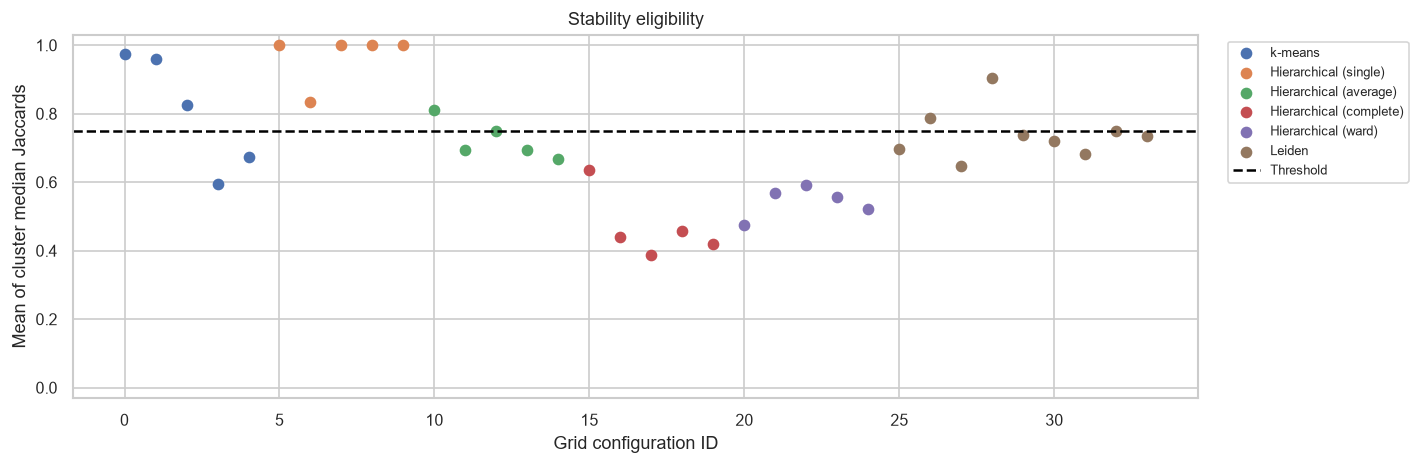

,method,cluster,original_cells,median_jaccard,q25,q75,evaluated_repeats,min_retained
0,k-means,0,848,0.970,0.939,0.979,10,664
1,k-means,1,1005,0.976,0.962,0.980,10,783
2,k-means,2,612,0.963,0.959,0.979,10,482
3,k-means,3,1535,0.984,0.981,0.988,10,1208
40,Hierarchical (single),0,3997,1.000,1.000,1.000,10,3197
41,Hierarchical (single),1,1,1.000,1.000,1.000,9,0
42,Hierarchical (single),2,1,1.000,1.000,1.000,10,1
43,Hierarchical (single),3,1,1.000,1.000,1.000,8,0
80,Hierarchical (average),0,3996,0.998,0.997,0.999,10,3196
81,Hierarchical (average),1,2,0.750,0.375,1.000,10,1


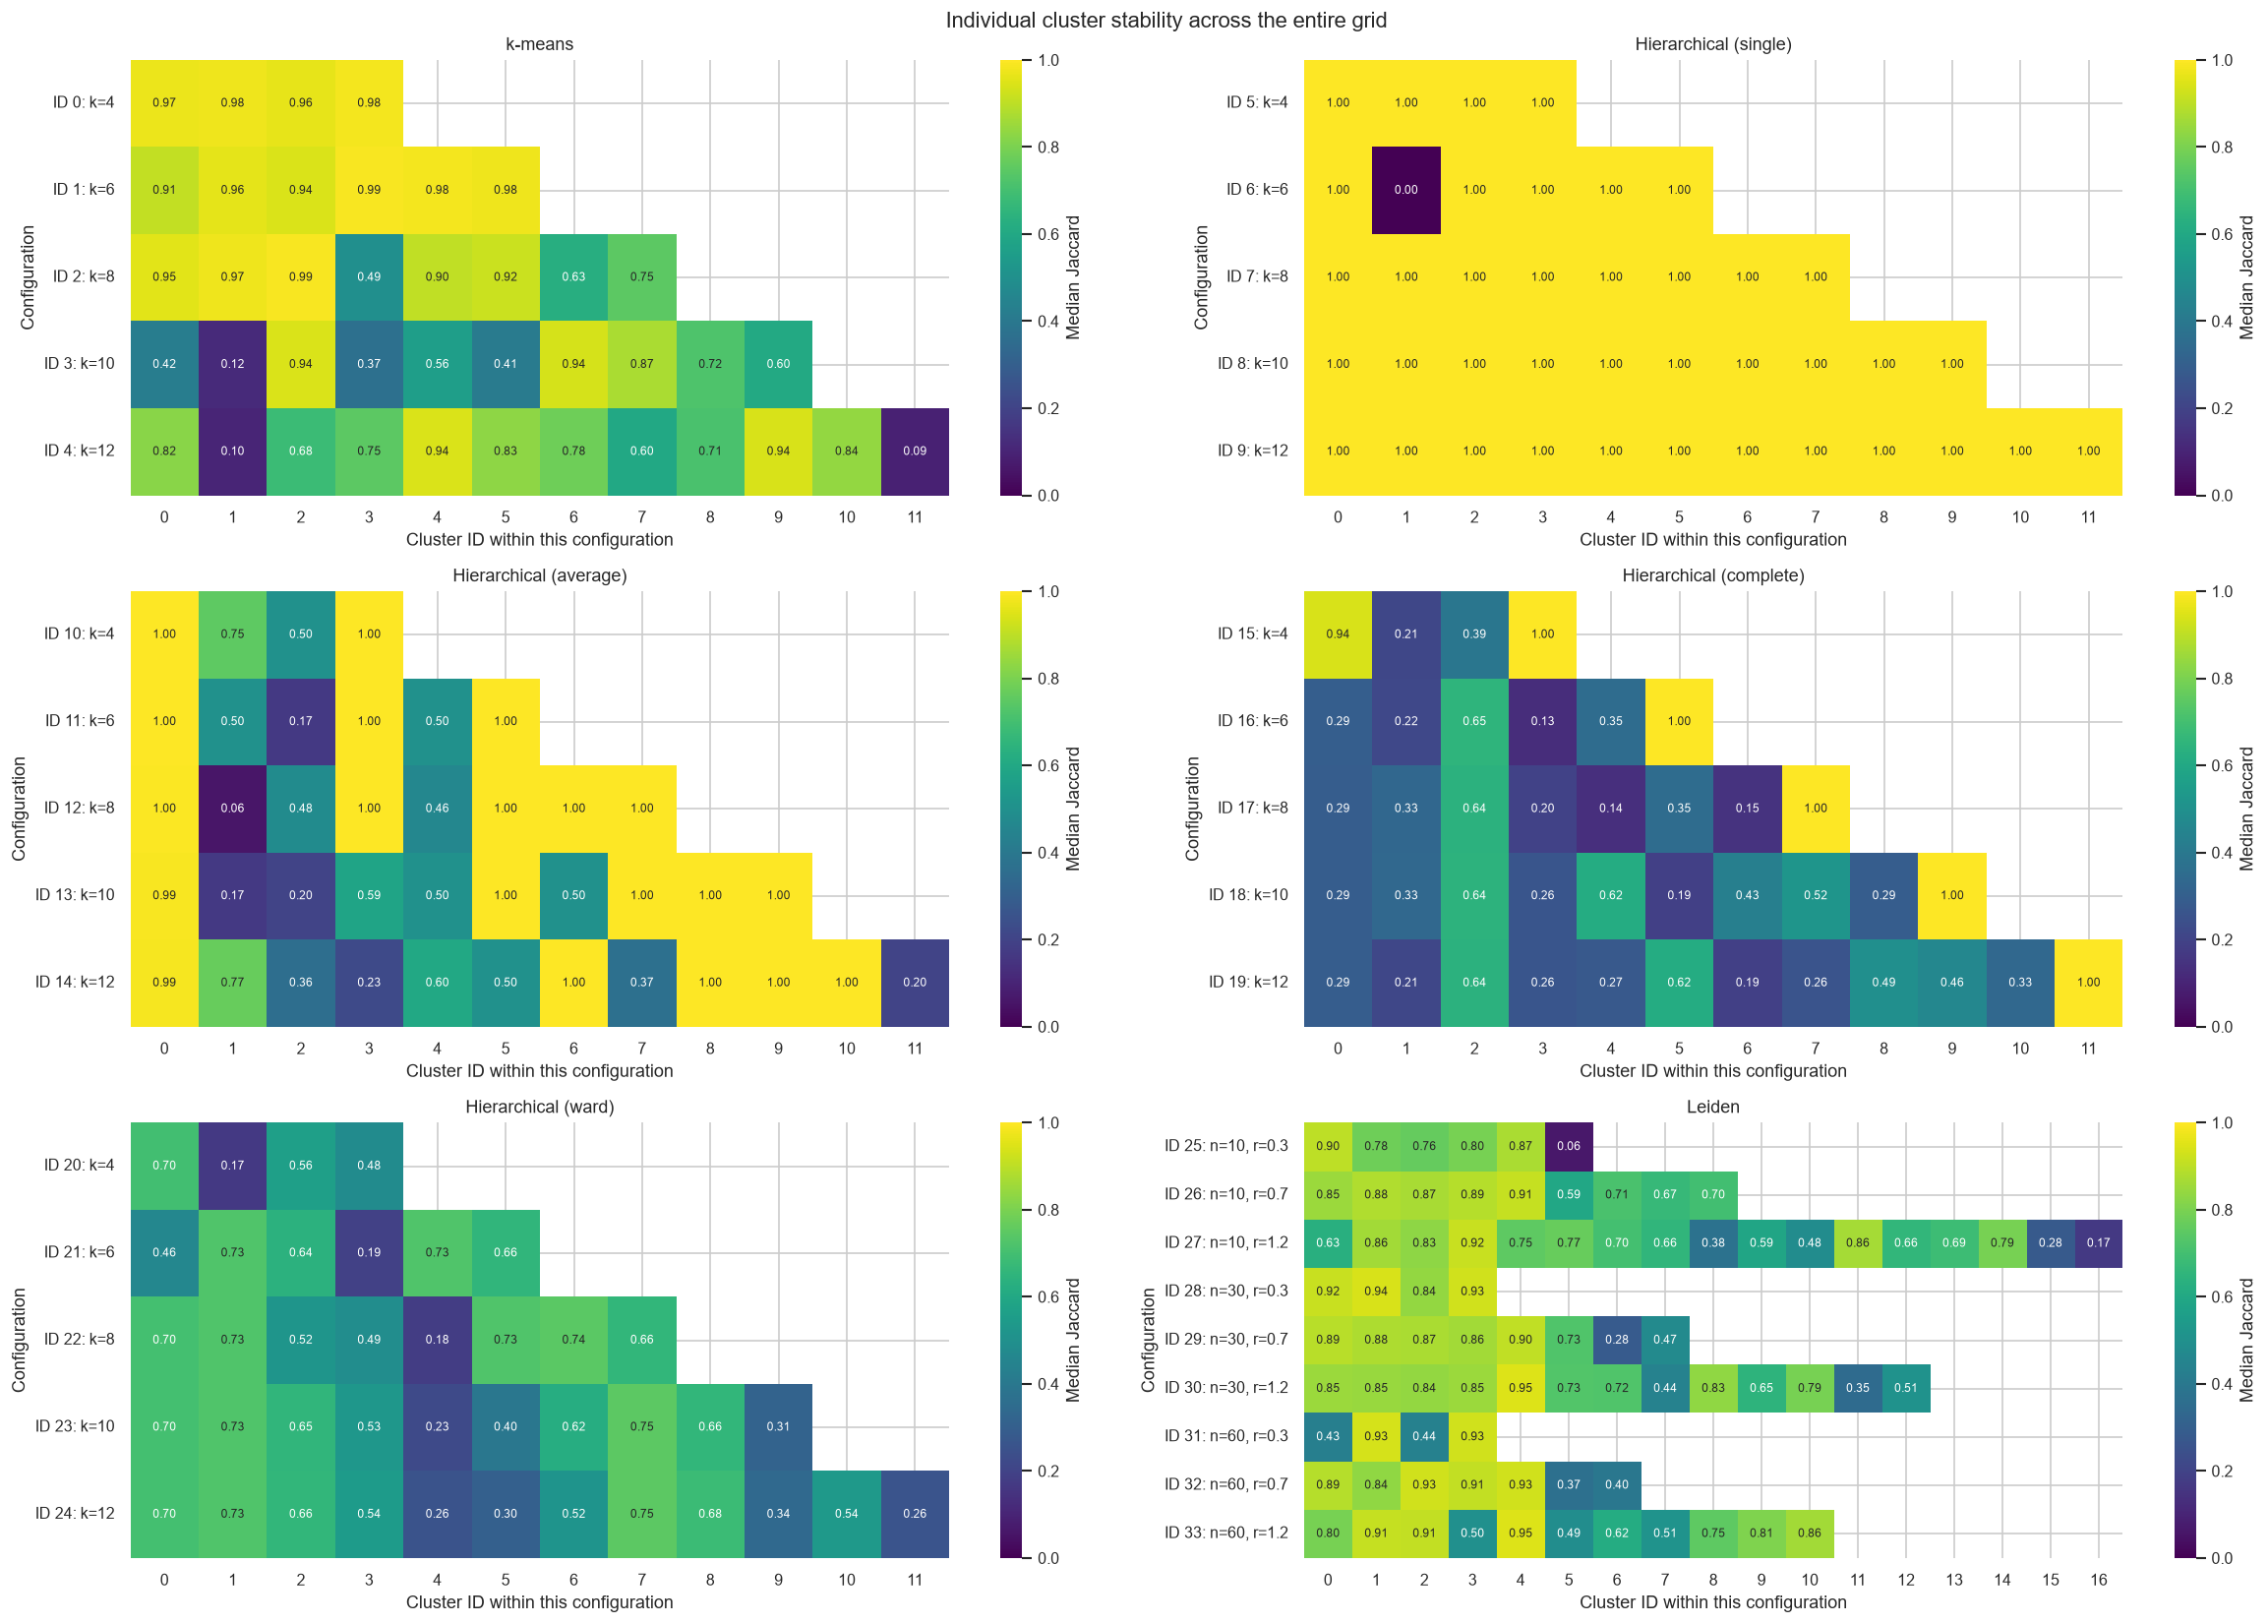

In [ ]:
def select_winners(results, use_stability, threshold):
    evaluated = results.copy()
    evaluated["eligible"] = np.isfinite(evaluated.score)
    if use_stability:
        if evaluated.stability.isna().all():
            raise ValueError("Run the stability cell first before enabling its filter.")
        evaluated["eligible"] &= evaluated.stability.ge(threshold)
    ranked = evaluated[evaluated.eligible].sort_values(
        "score", ascending=lower_is_better, kind="stable")
    selected = ranked.drop_duplicates("method").set_index("method")
    return evaluated, selected

# Toggle USE_STABILITY_FILTER or change STABILITY_THRESHOLD, then rerun from here.
grid, selected = select_winners(grid, USE_STABILITY_FILTER, STABILITY_THRESHOLD)
method_names = ["k-means"] + [f"Hierarchical ({link})" for link in LINKAGES] + ["Leiden"]
winners = selected.reindex(method_names)
winner_ids = {name: int(winners.loc[name, "id"]) for name in method_names
              if pd.notna(winners.loc[name, "id"])}
display(grid.round(3))
display(winners[["k", "neighbors", "resolution", "score", "stability",
                 "clusters", "largest_pct", "sizes"]].round(3))
for name in method_names:
    if name not in winner_ids:
        print(f"{name}: no eligible configuration; no fallback winner.")

if USE_STABILITY_FILTER:
    fig, ax = plt.subplots(figsize=(12, 4))
    for name, rows in grid.groupby("method", sort=False):
        ax.scatter(rows.id, rows.stability, label=name)
    ax.axhline(STABILITY_THRESHOLD, color="black", linestyle="--", label="Threshold")
    ax.set(xlabel="Grid configuration ID", ylabel="Mean of cluster median Jaccards",
           title="Stability eligibility", ylim=(-0.03, 1.03))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

# Keep the full per-cluster results available, especially for rare/singleton groups.
if USE_STABILITY_FILTER and winner_ids:
    selected_clusters = cluster_stability[cluster_stability.id.isin(winner_ids.values())].copy()
    selected_clusters["method"] = selected_clusters.id.map({v: k for k, v in winner_ids.items()})
    display(selected_clusters[["method", "cluster", "original_cells", "median_jaccard",
                               "q25", "q75", "evaluated_repeats", "min_retained"]].round(3))

# Inspect ALL cluster medians, not just eligible winners: a high mean can hide a weak group.
# Cluster numbers are local to each row/configuration; C0 need not represent the same cells.
if USE_STABILITY_FILTER:
    fig, axes = plt.subplots(3, 2, figsize=(20, 14))
    for ax, name in zip(axes.ravel(), method_names):
        runs = grid[grid.method == name]
        values = cluster_stability[cluster_stability.id.isin(runs.id)]
        matrix = values.pivot(index="id", columns="cluster", values="median_jaccard")
        row_labels = {}
        for row in runs.itertuples():
            setting = (f"k={int(row.k)}" if pd.notna(row.k)
                       else f"n={int(row.neighbors)}, r={row.resolution:g}")
            row_labels[row.id] = f"ID {row.id}: {setting}"
        matrix = matrix.rename(index=row_labels)
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
                    ax=ax, annot_kws={"fontsize": 7},
                    cbar_kws={"label": "Median Jaccard"})
        ax.set(title=name, xlabel="Cluster ID within this configuration", ylabel="Configuration")
    fig.suptitle("Individual cluster stability across the entire grid")
    fig.tight_layout()
    plt.show()


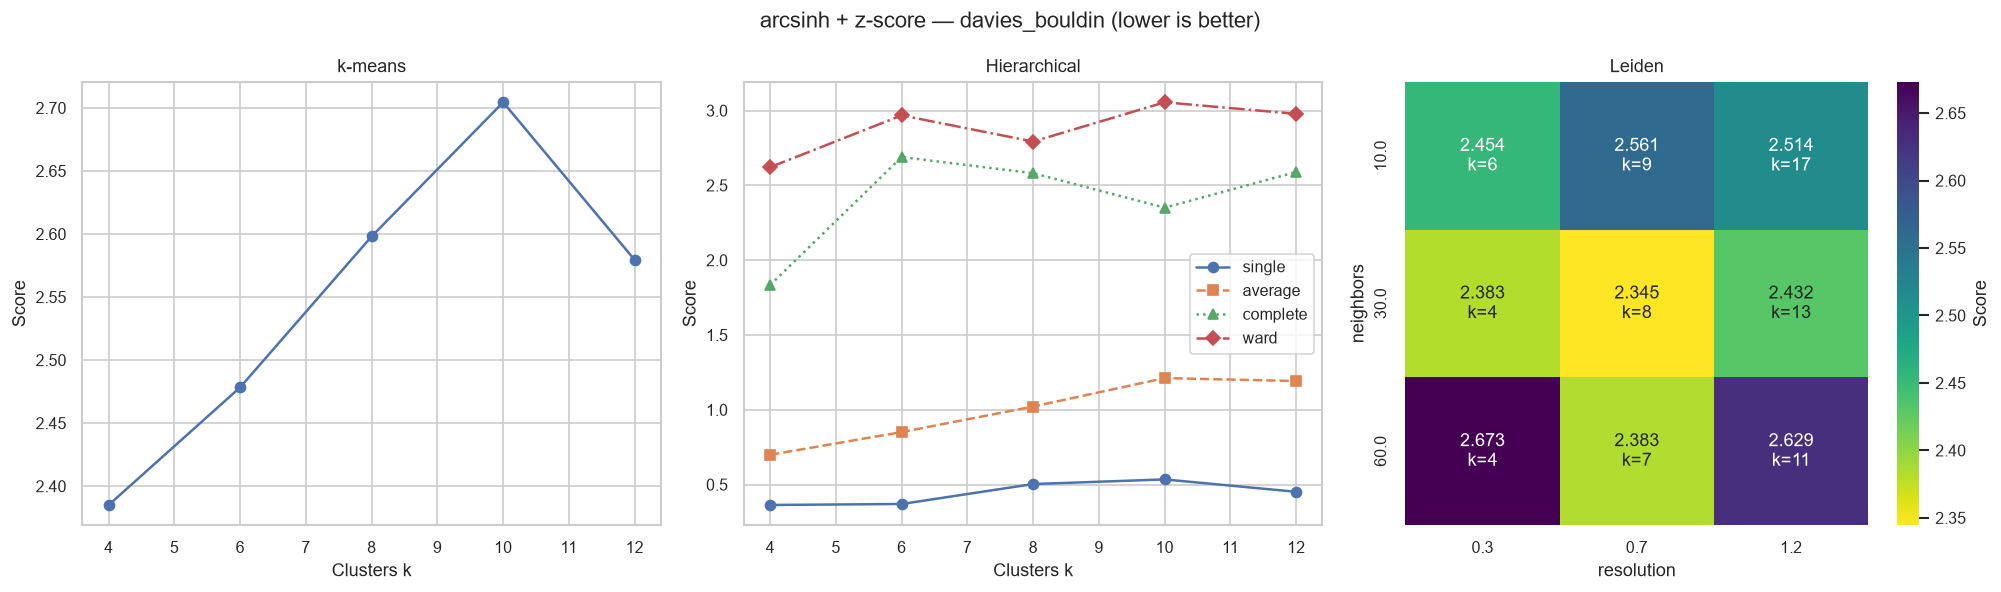

In [ ]:
direction = "lower is better" if lower_is_better else "higher is better"
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
rows = grid[grid.method == "k-means"]
axes[0].plot(rows.k, rows.score, marker="o")
axes[0].set(title="k-means", xlabel="Clusters k", ylabel="Score")

# Different styles keep almost overlapping linkage curves visible.
for link, style, marker in [("single", "-", "o"), ("average", "--", "s"), ("complete", ":", "^"), ("ward", "-.", "D")]:
    rows = grid[grid.method == f"Hierarchical ({link})"]
    axes[1].plot(rows.k, rows.score, linestyle=style, marker=marker, label=link)
axes[1].set(title="Hierarchical", xlabel="Clusters k", ylabel="Score")
axes[1].legend()

rows = grid[grid.method == "Leiden"]
scores = rows.pivot(index="neighbors", columns="resolution", values="score")
counts = rows.pivot(index="neighbors", columns="resolution", values="clusters")
labels = scores.copy().astype(str)
for neighbor in scores.index:
    for resolution in scores.columns:
        labels.loc[neighbor, resolution] = (
            f"{scores.loc[neighbor, resolution]:.3f}\nk={counts.loc[neighbor, resolution]}")
sns.heatmap(scores, annot=labels, fmt="", ax=axes[2],
            cmap="viridis_r" if lower_is_better else "viridis", cbar_kws={"label": "Score"})
axes[2].set_title("Leiden")
fig.suptitle(f"arcsinh + z-score — {METRIC} ({direction})")
fig.tight_layout()
plt.show()



## 6. Automatic descriptive marker annotation

- Rank all markers by (cluster median − whole-sample median) / whole-sample IQR on arcsinh intensities.
- TOP_MARKERS controls how many relatively high/low markers appear in each label.
- MIN_MARKER_EFFECT avoids highlighting negligible differences; it is a descriptive cutoff, not a statistical test.
- The labels describe expression patterns, not cell types, regulation or causal feature importance.
- Cluster medians do not establish co-expression in individual cells. Singleton profiles describe one event.
- A zero sample IQR leaves a marker unscored. The heatmaps use the same marker order/scale across methods.


,method,cluster,cells,higher_markers (IQR units),lower_markers (IQR units)
0,k-means,0,848,"CD19 (+1.36), HLA-DR (+0.54)",CD3 (-0.80)
1,k-means,1,1005,"CD34 (+1.34), CD33 (+0.77), 2DL4 (+0.73)",—
2,k-means,2,612,"NKp46 (+4.31), CD10 (+3.99), 2DL2-L3-S2 (+3.12)",—
3,k-means,3,1535,CD127 (+0.69),—
4,Hierarchical (single),0,3997,—,—
5,Hierarchical (single),1,1,"3DL1 (+35.69), NKp44 (+33.88), 3DL1-S1 (+31.88)",—
6,Hierarchical (single),2,1,"3DL1-S1 (+28.14), NKG2C (+25.73), 2DL3 (+17.17)",—
7,Hierarchical (single),3,1,"NKp44 (+40.99), CD117 (+34.80), TRAIL (+33.37)",CD25 (-0.55)
8,Hierarchical (average),0,3996,—,—
9,Hierarchical (average),1,2,"3DL1-S1 (+30.01), NKp44 (+19.84), 3DL1 (+19.14)",—


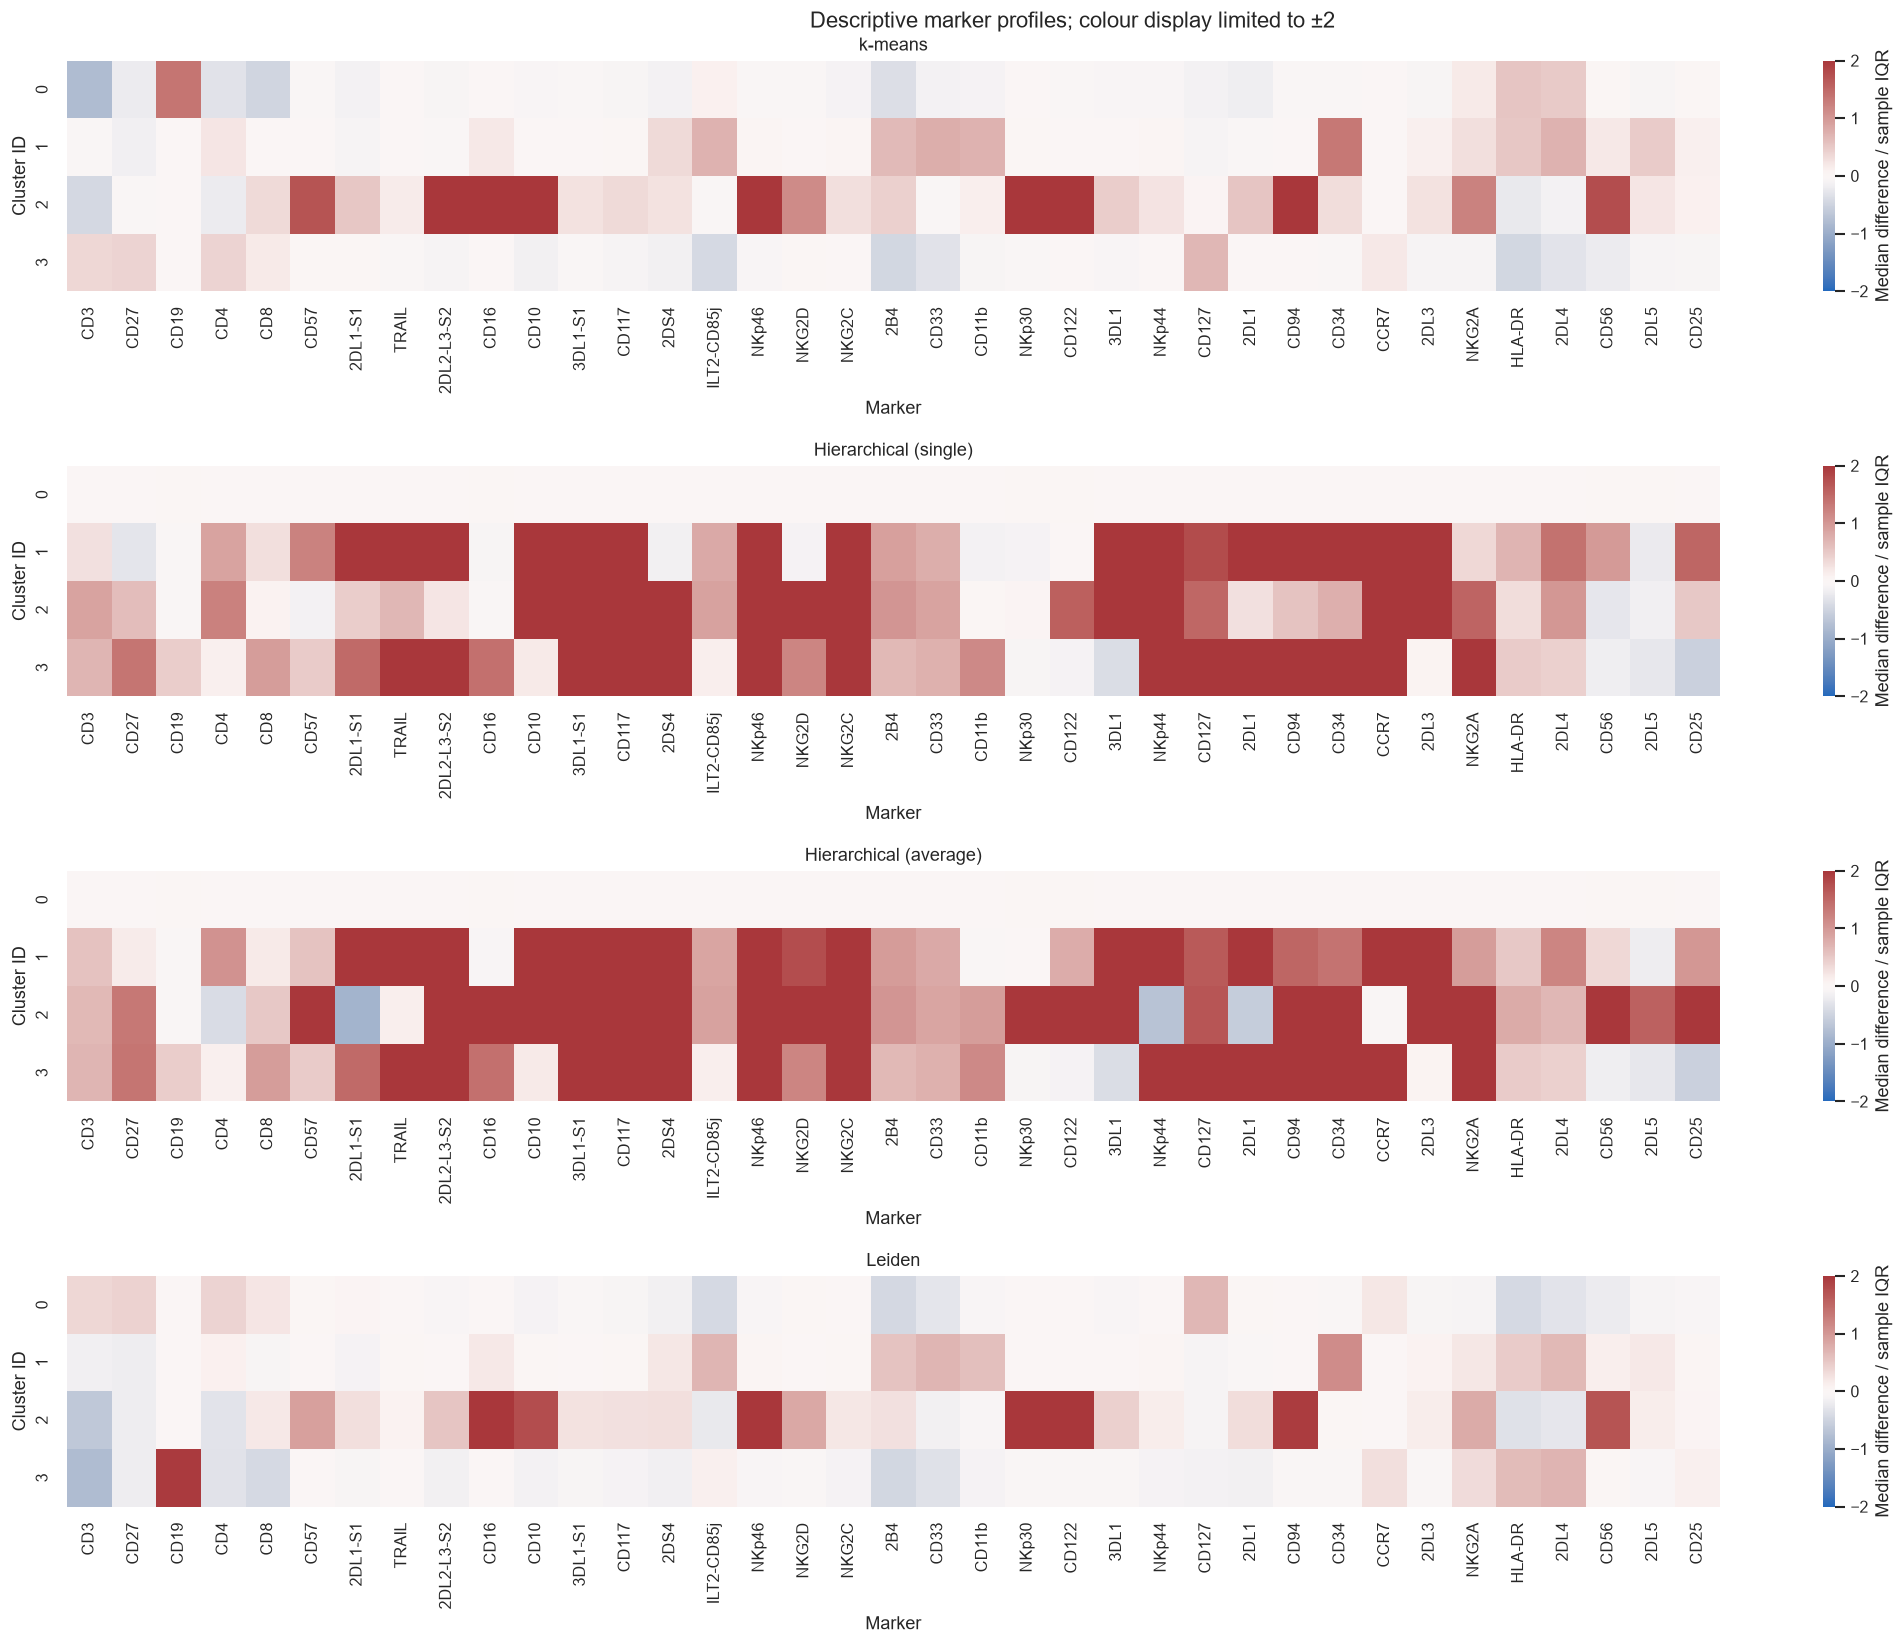

In [ ]:
# Descriptive marker annotation; these settings control label length and effect size.
TOP_MARKERS = 3
MIN_MARKER_EFFECT = 0.5  # Half a sample IQR; not a significance threshold.

expression = pd.DataFrame(arcsinh_values, columns=markers)
sample_median = expression.median()
# A zero IQR cannot define this relative scale: leave that marker unscored.
sample_iqr = (expression.quantile(0.75) - expression.quantile(0.25)).replace(0, np.nan)
profiles, relative_profiles, marker_annotations = {}, {}, {}
profile_rows = []

for name, run_id in winner_ids.items():
    labels = partitions[run_id]
    profiles[name] = expression.groupby(labels).median()
    # Same baseline and scale for every method, only for descriptive annotation.
    relative_profiles[name] = (profiles[name] - sample_median) / sample_iqr
    marker_annotations[name] = {}
    for cluster, values in relative_profiles[name].iterrows():
        # Rank all markers; the effect cutoff avoids labelling tiny differences as distinctive.
        higher = values[values >= MIN_MARKER_EFFECT].nlargest(TOP_MARKERS)
        lower = values[values <= -MIN_MARKER_EFFECT].nsmallest(TOP_MARKERS)
        descriptions = []
        if not higher.empty:
            descriptions.append("higher: " + ", ".join(higher.index))
        if not lower.empty:
            descriptions.append("lower: " + ", ".join(lower.index))
        marker_annotations[name][cluster] = (
            "; ".join(descriptions) if descriptions else "No marked median difference")
        profile_rows.append({
            "method": name, "cluster": cluster, "cells": int((labels == cluster).sum()),
            "higher_markers (IQR units)": ", ".join(f"{m} ({v:+.2f})" for m, v in higher.items()) or "—",
            "lower_markers (IQR units)": ", ".join(f"{m} ({v:+.2f})" for m, v in lower.items()) or "—",
        })

marker_summary = pd.DataFrame(profile_rows)
display(marker_summary)
# Keep every marker visible; identical column order and colour scale across methods.
if winner_ids:
    fig, axes = plt.subplots(len(winner_ids), 1,
                             figsize=(18, max(4, 3.5 * len(winner_ids))), squeeze=False)
    for ax, name in zip(axes.ravel(), winner_ids):
        sns.heatmap(relative_profiles[name], cmap="vlag", center=0, vmin=-2, vmax=2,
                    ax=ax, cbar_kws={"label": "Median difference / sample IQR"})
        ax.set(title=name, xlabel="Marker", ylabel="Cluster ID")
    fig.suptitle("Descriptive marker profiles; colour display limited to ±2")
    fig.tight_layout()
    plt.show()
else:
    print("No eligible winners to describe.")


## 7. Results

- The table below is generated from the latest executed selection (winners), not typed manually.
- After changing the threshold, rerun section 5 and this table. Existing outputs do not update when only a setting is edited.
- The mean weights clusters equally; it can hide weak groups. Inspect the individual-cluster heatmaps.
- High stability, especially for isolated cells, is not evidence of a biologically useful population.


In [ ]:
# Build the report from the actual selection; no hard-coded winners, scores or threshold.
# Re-execute section 5 first after changing the stability filter or threshold.
report_rows = []
for method, row in winners.iterrows():
    label = method.replace("Hierarchical (", "").replace(")", "")
    if method.startswith("Hierarchical"):
        label = f"{label.capitalize()} linkage"

    if pd.isna(row["score"]):
        parameters, score, stability = "No eligible configuration", "—", "—"
    else:
        if method == "Leiden":
            parameters = (f"{int(row['neighbors'])} neighbours, resolution={row['resolution']:g}; "
                          f"{int(row['clusters'])} clusters")
        else:
            parameters = f"k={int(row['k'])}"
        score = f"{row['score']:.3f}"
        stability = f"{row['stability']:.3f}" if pd.notna(row["stability"]) else "Not evaluated"

    report_rows.append({"Method": label, "Selected parameters": parameters,
                        f"{METRIC} {'↓' if lower_is_better else '↑'}": score,
                        "Mean stability": stability})

results_table = pd.DataFrame(report_rows)
display(results_table)


Method,Selected parameters,davies_bouldin ↓,Mean stability
k-means,k=4,2.385,0.973
Single linkage,k=4,0.364,1.000
Average linkage,k=4,0.699,0.812
Complete linkage,No eligible configuration,—,—
Ward linkage,No eligible configuration,—,—
Leiden,"30 neighbours, resolution=0.3; 4 clusters",2.383,0.905


## 8. Plots annotated with marker profiles

- Keep cluster IDs and cell counts. Automatically add the most relatively high/low markers from section 6.
- No manual cell-type assignments. Shared UMAP is for display; clustering/scoring use X.
- Rerun section 6 and these plots after selection changes. Marker labels update automatically.


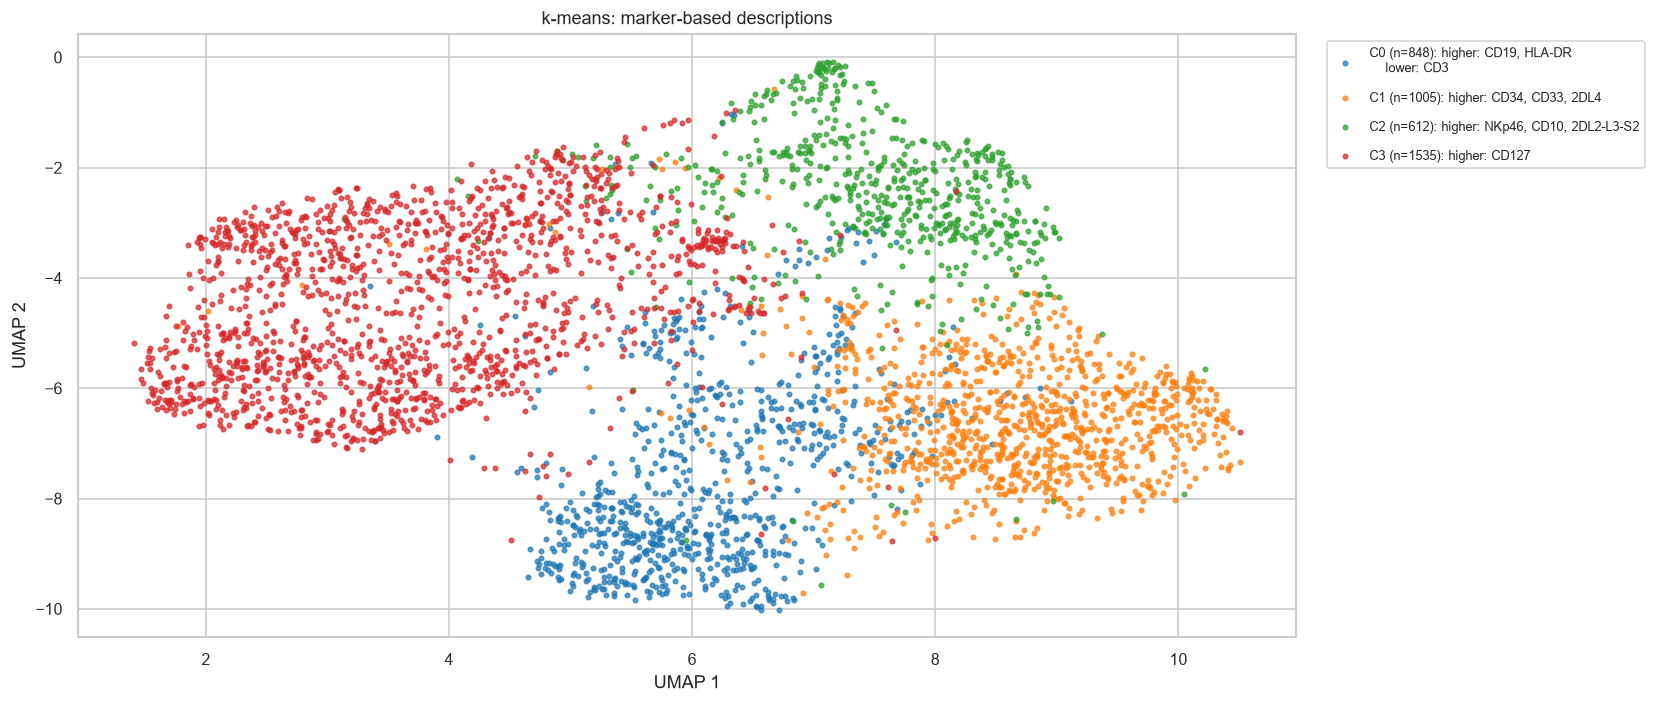

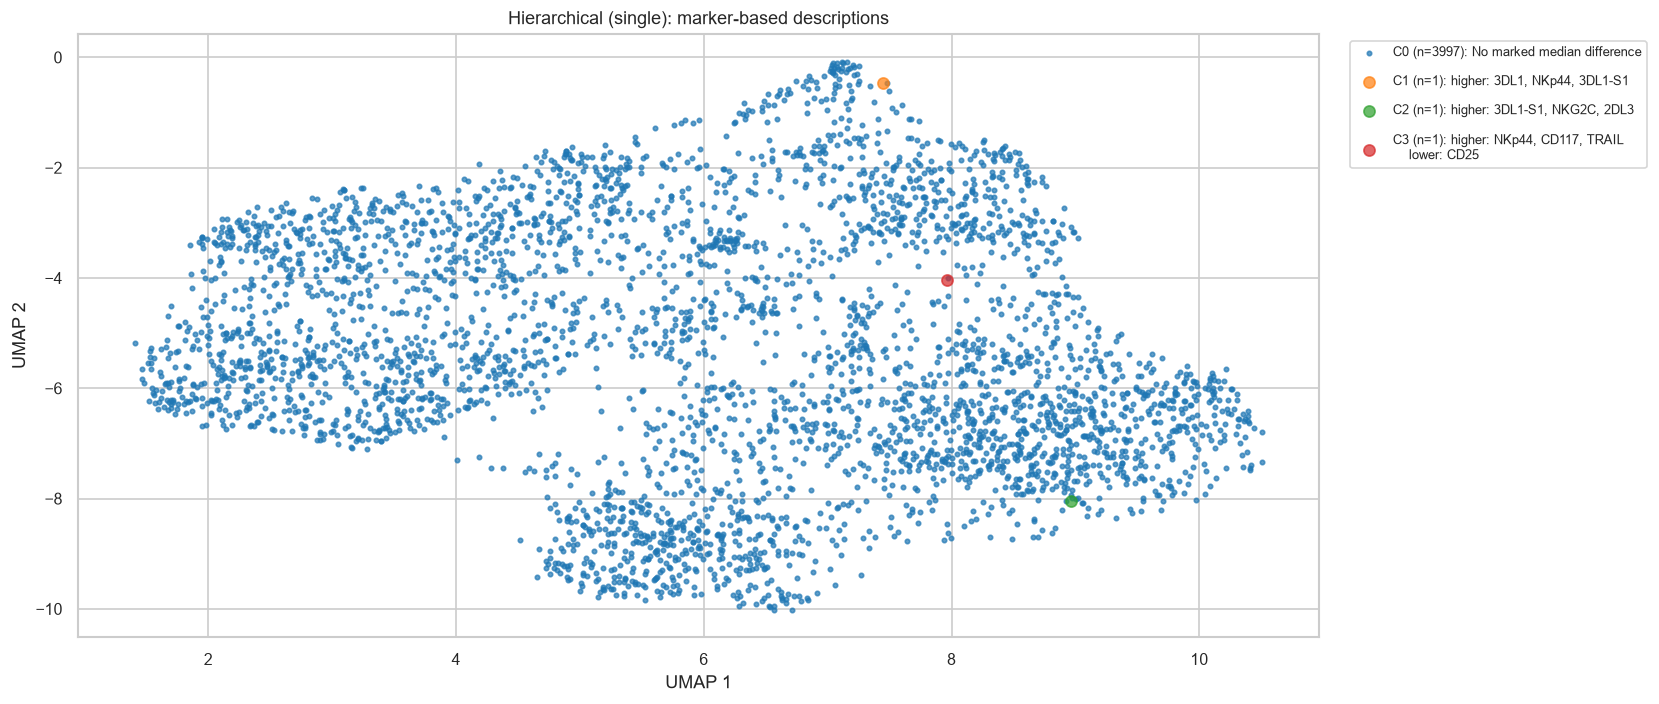

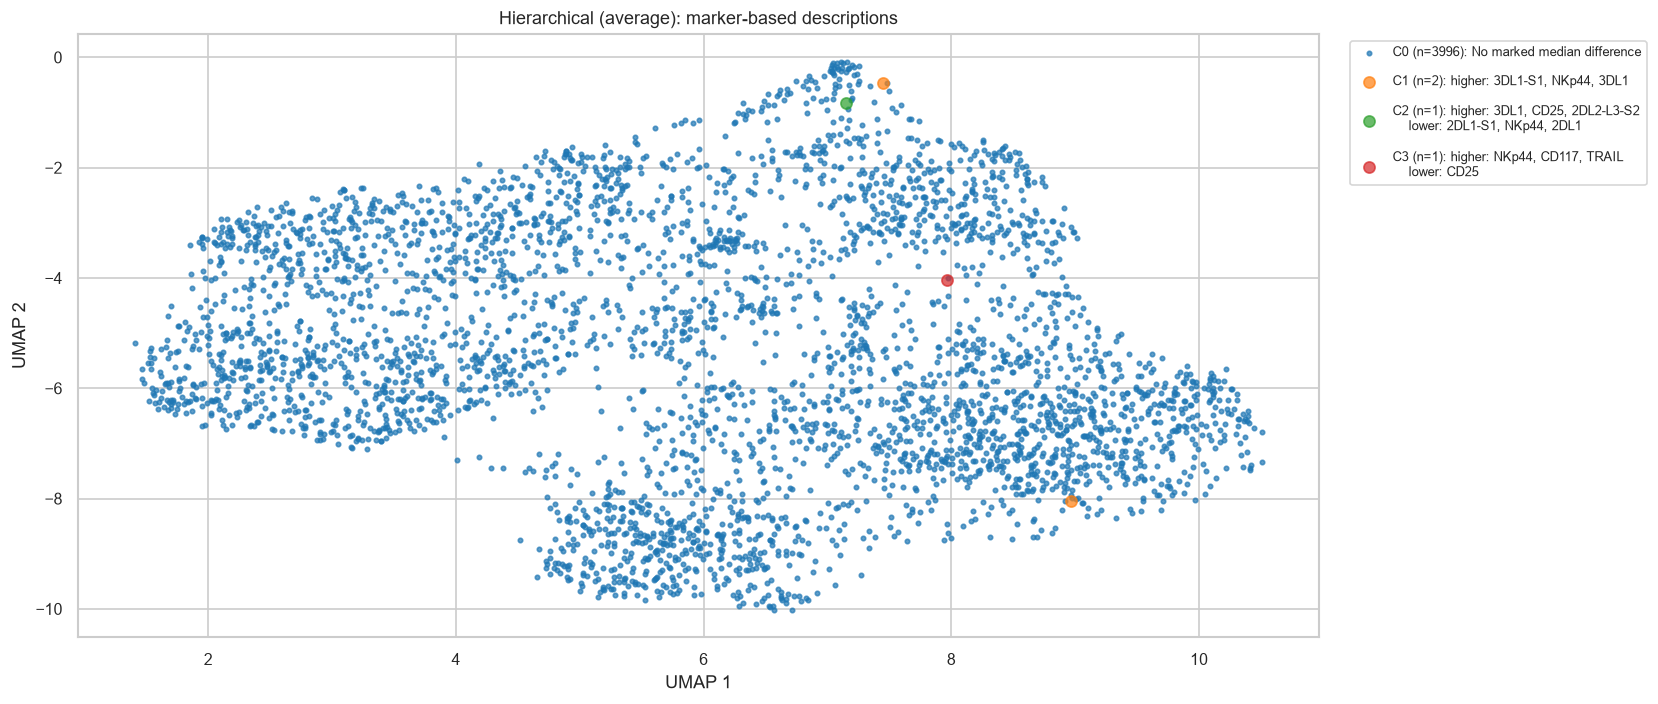

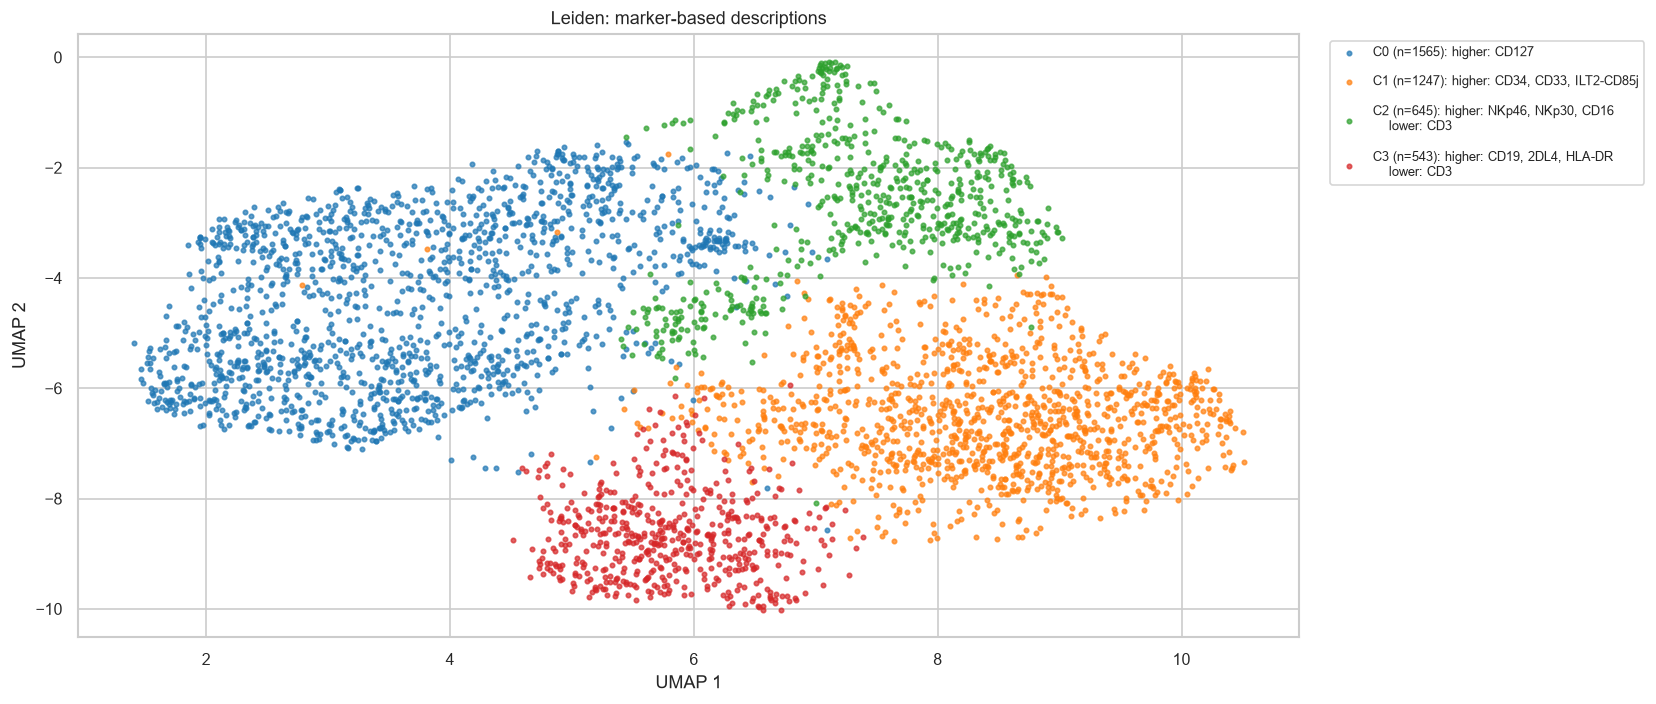

In [ ]:
# Labels come from marker profiles; no manual cell-type names or hard-coded run IDs.
if winner_ids:
    plot_data = sc.AnnData(X)
    sc.pp.neighbors(plot_data, n_neighbors=30, use_rep="X", random_state=SEED)
    sc.tl.umap(plot_data, min_dist=0.3, random_state=SEED)
    embedding = plot_data.obsm["X_umap"]

    for name in ["k-means"] + [f"Hierarchical ({link})" for link in LINKAGES] + ["Leiden"]:
        if name not in winner_ids:
            continue
        labels = partitions[winner_ids[name]]
        fig, ax = plt.subplots(figsize=(14, 6))
        colors = sns.color_palette("tab10", len(np.unique(labels)))
        for color, cluster in zip(colors, sorted(np.unique(labels))):
            selected = labels == cluster
            description = marker_annotations[name][cluster].replace("; ", "\n    ")
            ax.scatter(embedding[selected, 0], embedding[selected, 1],
                       s=45 if selected.sum() <= 2 else 7, alpha=0.7, color=color,
                       label=f"C{cluster} (n={selected.sum()}): {description}")
        ax.set(title=f"{name}: marker-based descriptions", xlabel="UMAP 1", ylabel="UMAP 2")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, labelspacing=1.2)
        fig.tight_layout()
        plt.show()
else:
    print("No eligible configurations; no winner plots.")


References: [Jaccard stability in single-cell clustering](https://pmc.ncbi.nlm.nih.gov/articles/PMC8352506/), [sklearn metrics](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation), [SciPy linkage and Ward](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html), [Scanpy Leiden](https://scanpy.readthedocs.io/en/stable/api/generated/scanpy.tl.leiden.html).